In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=False,
    download=True,
    transform=transform
)

57.7%IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

100.0%
/Users/ishwarya/Desktop/kubernetes-ml-deployment/venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [4]:
print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Training samples: 50000
Test samples: 10000


In [5]:
classes = train_dataset.classes
print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label index:", label)
print("Class name:", classes[label])

Image shape: torch.Size([3, 32, 32])
Label index: 6
Class name: frog


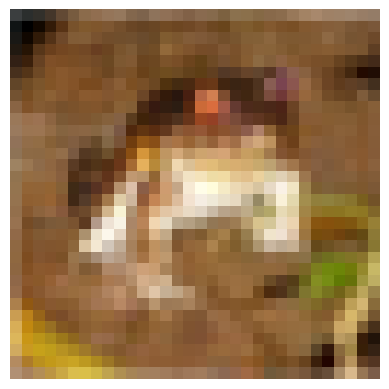

In [7]:
def show_image(img_tensor):
    img = img_tensor.permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.axis("off")
    plt.show()

show_image(image)

In [26]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [27]:
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Batch image shape: torch.Size([64, 3, 32, 32])
Batch label shape: torch.Size([64])


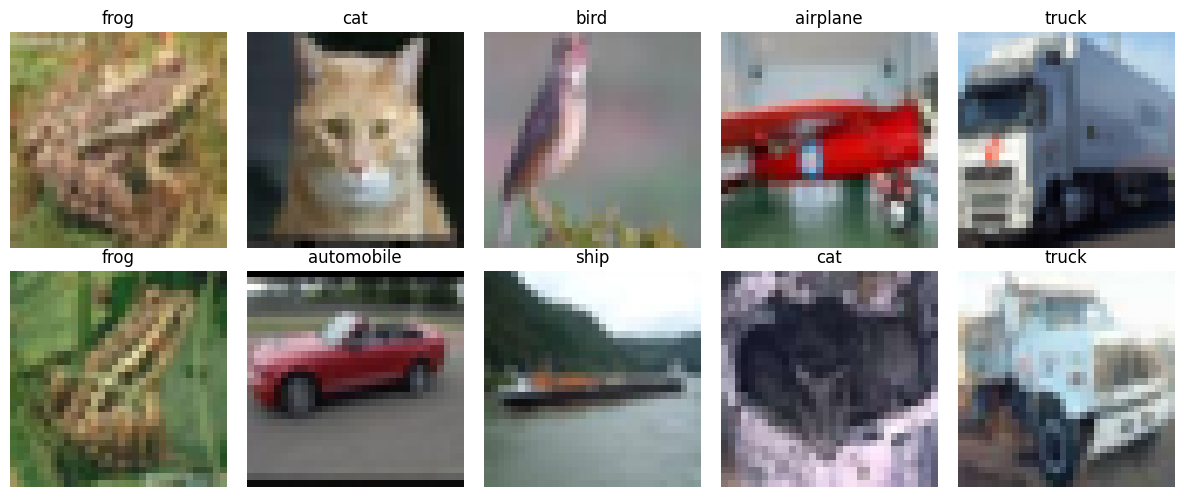

In [28]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i in range(10):
    img = images[i].permute(1, 2, 0).numpy()
    lbl = labels[i].item()

    ax = axes[i // 5, i % 5]
    ax.imshow(img)
    ax.set_title(train_dataset.classes[lbl])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [30]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [31]:
model = SimpleCNN()
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [32]:
outputs = model(images)
print("Output shape:", outputs.shape)

Output shape: torch.Size([64, 10])


In [33]:
print(outputs[0])

tensor([-0.0414,  0.0280,  0.0417, -0.0018,  0.0566, -0.0566,  0.0296,  0.0552,
        -0.0359, -0.0458], grad_fn=<SelectBackward0>)


In [34]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [35]:
model.train()

running_loss = 0.0

for images, labels in train_loader:
    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    running_loss += loss.item()

print("Average training loss:", running_loss / len(train_loader))

Average training loss: 1.4629737762234094


In [36]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 58.64%


In [37]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [38]:
train_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=True,
    download=False,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=False,
    download=False,
    transform=transform
)

In [39]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [40]:
model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [41]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f} - Test Accuracy: {accuracy:.2f}%")

Epoch [1/5] - Train Loss: 1.3283 - Test Accuracy: 61.82%
Epoch [2/5] - Train Loss: 0.9526 - Test Accuracy: 66.17%
Epoch [3/5] - Train Loss: 0.8091 - Test Accuracy: 69.20%
Epoch [4/5] - Train Loss: 0.6942 - Test Accuracy: 71.82%
Epoch [5/5] - Train Loss: 0.5932 - Test Accuracy: 73.15%


In [42]:
torch.save(model.state_dict(), "../models/cnn_cifar10.pth")
print("Model saved successfully!")

Model saved successfully!
